In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Setup and Libraries**

In [30]:
%pip install lime
%pip install rbo
%pip install shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import rbo
import warnings

from lime.lime_tabular import LimeTabularExplainer
from itertools import combinations
from scipy.stats import wasserstein_distance
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    auc,
    roc_auc_score,
    accuracy_score,
    log_loss
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.random.seed(42)

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-darkgrid")

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.

  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached numpy-2.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (19.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rbo 0.1.3 requires numpy<2.0,>=1.18, but you have numpy 2.0.2 which is incompatible.


**Load and Prepare Elliptic Data**

Load the Elliptic features and labels, merge them, keep only labeled transactions, and sort everything temporally.

In [31]:
FEATURES_PATH = "/content/drive/MyDrive/Thesis 4/elliptic_txs_features.csv"
CLASSES_PATH = "/content/drive/MyDrive/Thesis 4/elliptic_txs_classes.csv"

df_features = pd.read_csv(FEATURES_PATH, header=None)
df_classes = pd.read_csv(CLASSES_PATH)

feature_cols_raw = ["txId", "time_step"] + [f"feature_{i}" for i in range(1, df_features.shape[1] - 1)]
df_features.columns = feature_cols_raw

df_classes["class"] = df_classes["class"].replace({"unknown": 3, "1": 1, "2": 0}).astype(int)

df = df_features.merge(df_classes, on="txId", how="inner")
df = df[df["class"].isin([0, 1])].copy()
df = df.sort_values(["time_step", "txId"]).reset_index(drop=True)

feature_cols = [c for c in df.columns if c.startswith("feature_")]

print(f"Dataset loaded successfully. Shape: {df.shape}")
print(f"Time step range: {df['time_step'].min()} to {df['time_step'].max()}")
print(f"Fraud rate: {df['class'].mean():.4f}")
print(f"Number of features: {len(feature_cols)}")

df.head()

Dataset loaded successfully. Shape: (46564, 168)
Time step range: 1 to 49
Fraud rate: 0.0976
Number of features: 165


,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class
0,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,-0.118555,0.300047,-0.145947,2.017758,1.189967,-0.042955,-0.013282,0.054659,-0.118754,-0.121849,-0.106751,-1.373657,-1.371460,-0.139302,-0.148638,-0.080147,-0.155297,-0.010763,-0.012107,-0.139303,-0.148633,-0.080147,-0.155297,-0.010669,-0.012005,-0.024667,-0.031270,-0.023045,-0.026213,0.001428,0.001483,-0.225929,-0.238157,-0.075256,-0.233692,0.037468,0.043444,-0.226790,-0.242832,-0.097895,-0.235485,0.036577,0.042345,1.779449,1.335947,-0.232553,1.637156,0.048767,0.052956,-0.038211,-0.172643,-0.163004,-0.160543,0.923473,0.923011,-0.038207,-0.172632,-0.162993,-0.160536,0.923516,0.923110,-0.017032,-0.030025,-0.017639,-0.015070,2.146899,2.148396,-0.094058,-0.263316,-0.249584,-0.262486,1.133527,1.135947,-0.056814,-0.262032,-0.254938,-0.258681,1.125590,1.128038,1.056058,0.745604,0.529777,1.065507,1.135523,1.135279,-0.169418,-0.173724,-0.056760,-0.179202,2.105260,1.256720,-1.624659,-1.495881,1.607475,-1.543580,-0.086866,1.339449,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.115534,-0.021730,-0.087925,-0.02606,-0.02766,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.104489,-0.173559,-0.159261,-0.180144,-1.159649,-1.160129,-1.373723,-1.352048,-0.291104,-1.402174,1.342003,1.340733,-0.168742,-0.458162,-0.424672,-0.440022,0.143001,0.142525,-0.968903,-1.943850,-1.059868,-1.678997,0.185597,0.185492,-0.216814,-0.611769,-0.569626,-0.607306,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,0
1,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,5.252974,-0.049707,5.327423,-0.028741,-0.035391,265.263236,-0.013282,-0.057401,0.096439,-0.167593,-0.175293,-0.474922,-1.371460,1.828567,1.107041,-0.080147,1.512162,-0.010763,-0.012107,1.828864,1.107130,-0.080147,1.512340,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.210772,-0.223886,-0.075256,-0.218857,0.037468,0.043444,-0.210158,-0.226564,-0.097895,-0.218953,0.036

**Initial EDA Overview**


Basic dataset overview
(46564, 168)
txId           int64
time_step      int64
feature_1    float64
feature_2    float64
feature_3    float64
dtype: object
class
0    42019
1     4545
Name: count, dtype: int64
class
0    0.902392
1    0.097608
Name: proportion, dtype: float64

Transactions per time step:
           Total_Transactions  Fraud_Count  Fraud_Rate
time_step                                             
1                        2147           17      0.0079
2                        1117           18      0.0161
3                        1279           11      0.0086
4                        1440           30      0.0208
5                        1882            8      0.0043
6                         485            5      0.0103
7                        1203          102      0.0848
8                        1165           67      0.0575
9                         778          248      0.3188
10                        972           18      0.0185
11                        696      

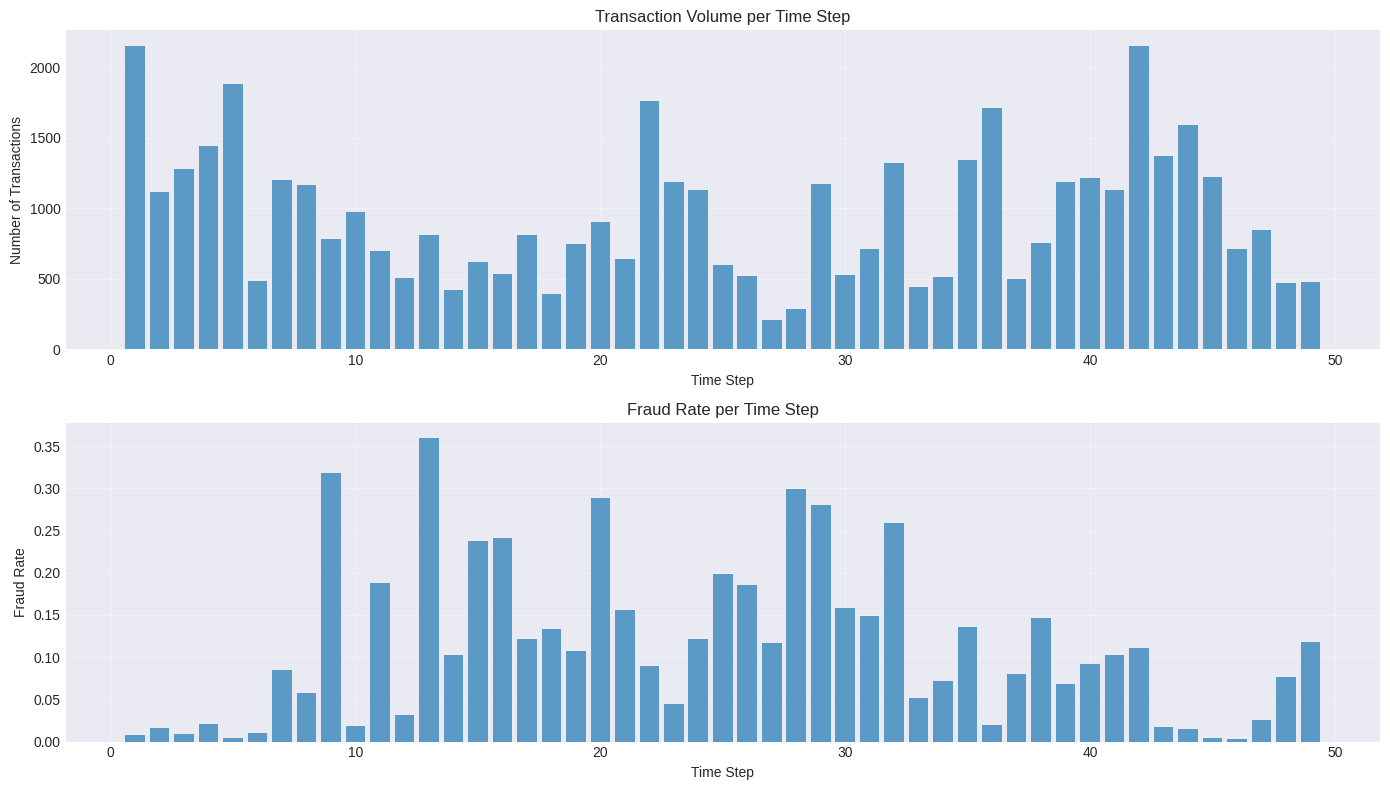

In [32]:
print("Basic dataset overview")
print(df.shape)
print(df.dtypes.head())
print(df["class"].value_counts(dropna=False))
print(df["class"].value_counts(normalize=True, dropna=False))

time_step_counts = df.groupby("time_step").agg(
    Total_Transactions=("txId", "count"),
    Fraud_Count=("class", "sum"),
    Fraud_Rate=("class", "mean")
).round(4)

print("\nTransactions per time step:")
print(time_step_counts)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(time_step_counts.index, time_step_counts["Total_Transactions"], alpha=0.7)
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_title("Transaction Volume per Time Step")
axes[0].grid(True, alpha=0.3)

axes[1].bar(time_step_counts.index, time_step_counts["Fraud_Rate"], alpha=0.7)
axes[1].set_xlabel("Time Step")
axes[1].set_ylabel("Fraud Rate")
axes[1].set_title("Fraud Rate per Time Step")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Reference Scaler for Drift Computation**

Fit one shared reference scaler used only for covariate drift calculations.

In [33]:
reference_scaler = StandardScaler()
reference_scaler.fit(df[feature_cols].values)

print(f"Reference scaler fitted on {len(df)} rows and {len(feature_cols)} features")

Reference scaler fitted on 46564 rows and 165 features


**Temporal Configuration**

Define the rolling temporal setup with window length, retrain step, evaluation horizon, number of replicas, and fraud threshold.

In [34]:
WINDOW_LENGTH = 15
RETRAIN_STEP = 5
PAIR_STRIDE = 3
EVAL_HORIZON = 4
NUM_REPLICAS = 5
FRAUD_THRESHOLD = 0.5

all_steps = sorted(df["time_step"].unique())
num_time_steps = len(all_steps)

print("Configuration:")
print(f"  Window length L: {WINDOW_LENGTH}")
print(f"  Retrain step S (A -> B): {RETRAIN_STEP}")
print(f"  Pair stride P (pair -> next pair): {PAIR_STRIDE}")
print(f"  Evaluation horizon H: {EVAL_HORIZON}")
print(f"  Number of replicas R: {NUM_REPLICAS}")
print(f"  Fraud threshold: {FRAUD_THRESHOLD}")
print(f"  Total available time steps: {num_time_steps}")

Configuration:
  Window length L: 15
  Retrain step S (A -> B): 5
  Pair stride P (pair -> next pair): 3
  Evaluation horizon H: 4
  Number of replicas R: 5
  Fraud threshold: 0.5
  Total available time steps: 49


**Temporal Helper Functions**

Build all leakage-free temporal slicing utilities for windows, validation splits, and evaluation slices.

In [35]:
def get_window_data(df, end_step, window_length):
    start_step = end_step - window_length + 1
    return df[df["time_step"].between(start_step, end_step)].copy()

def get_eval_slice(df, start_step, horizon):
    return df[df["time_step"].between(start_step + 1, start_step + horizon)].copy()

def split_window_train_valid(window_data, train_frac=0.8):
    ordered_steps = sorted(window_data["time_step"].unique())
    split_idx = max(1, int(np.floor(len(ordered_steps) * train_frac)))
    split_idx = min(split_idx, len(ordered_steps) - 1)

    train_steps = ordered_steps[:split_idx]
    valid_steps = ordered_steps[split_idx:]

    train_data = window_data[window_data["time_step"].isin(train_steps)].copy()
    valid_data = window_data[window_data["time_step"].isin(valid_steps)].copy()

    return train_data, valid_data, train_steps, valid_steps

def make_xy(data, feature_cols, target_col="class"):
    X = data[feature_cols].copy()
    y = data[target_col].astype(int).copy()
    return X, y

def fit_imputer(X_train):
    imputer = SimpleImputer(strategy="median")
    imputer.fit(X_train)
    return imputer

def build_pair_data(df, feature_cols, k_a, retrain_step, window_length, eval_horizon):
    k_b = k_a + retrain_step

    window_a = get_window_data(df, k_a, window_length)
    window_b = get_window_data(df, k_b, window_length)
    eval_slice = get_eval_slice(df, k_b, eval_horizon)

    train_a, valid_a, train_steps_a, valid_steps_a = split_window_train_valid(window_a, train_frac=0.8)
    train_b, valid_b, train_steps_b, valid_steps_b = split_window_train_valid(window_b, train_frac=0.8)

    X_train_a, y_train_a = make_xy(train_a, feature_cols)
    X_valid_a, y_valid_a = make_xy(valid_a, feature_cols)

    X_train_b, y_train_b = make_xy(train_b, feature_cols)
    X_valid_b, y_valid_b = make_xy(valid_b, feature_cols)

    X_eval, y_eval = make_xy(eval_slice, feature_cols)

    imputer_a = fit_imputer(X_train_a)
    imputer_b = fit_imputer(X_train_b)

    X_train_a = pd.DataFrame(imputer_a.transform(X_train_a), columns=feature_cols, index=X_train_a.index)
    X_valid_a = pd.DataFrame(imputer_a.transform(X_valid_a), columns=feature_cols, index=X_valid_a.index)
    X_eval_a = pd.DataFrame(imputer_a.transform(X_eval), columns=feature_cols, index=X_eval.index)

    X_train_b = pd.DataFrame(imputer_b.transform(X_train_b), columns=feature_cols, index=X_train_b.index)
    X_valid_b = pd.DataFrame(imputer_b.transform(X_valid_b), columns=feature_cols, index=X_valid_b.index)
    X_eval_b = pd.DataFrame(imputer_b.transform(X_eval), columns=feature_cols, index=X_eval.index)

    return {
        "k_a": k_a,
        "k_b": k_b,
        "window_a": window_a,
        "window_b": window_b,
        "eval_slice": eval_slice,
        "train_a": train_a,
        "valid_a": valid_a,
        "train_b": train_b,
        "valid_b": valid_b,
        "train_steps_a": train_steps_a,
        "valid_steps_a": valid_steps_a,
        "train_steps_b": train_steps_b,
        "valid_steps_b": valid_steps_b,
        "X_train_a": X_train_a,
        "y_train_a": y_train_a,
        "X_valid_a": X_valid_a,
        "y_valid_a": y_valid_a,
        "X_train_b": X_train_b,
        "y_train_b": y_train_b,
        "X_valid_b": X_valid_b,
        "y_valid_b": y_valid_b,
        "X_eval_raw": X_eval,
        "y_eval": y_eval,
        "X_eval_a": X_eval_a,
        "X_eval_b": X_eval_b
    }

def get_valid_pairs(all_steps, window_length, retrain_step, eval_horizon, pair_stride=1):
    valid_pairs = []
    min_end = window_length - 1
    max_end = max(all_steps) - retrain_step - eval_horizon

    for k_a in range(min_end, max_end + 1, pair_stride):
        k_b = k_a + retrain_step
        if k_b + eval_horizon <= max(all_steps):
            valid_pairs.append((k_a, k_b))

    return valid_pairs

**Random Forest Training and Prediction Utilities**

Train Random Forest replicas, using only the first 80% of each window for fitting and the last 20% for validation reporting.

In [36]:
def build_rf_model(random_state=42):
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        bootstrap=True,
        n_jobs=-1,
        random_state=random_state
    )

def bootstrap_sample(X, y, seed):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X), size=len(X), replace=True)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)

def evaluate_binary_predictions(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)

    pr_auc = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score) if len(np.unique(y_true)) > 1 else np.nan
    acc = accuracy_score(y_true, y_pred)

    try:
        ll = log_loss(y_true, y_score, labels=[0, 1])
    except:
        ll = np.nan

    return {
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "accuracy": acc,
        "log_loss": ll
    }

def train_rf_replicas(X_train, y_train, X_valid, y_valid, num_replicas=5, base_seed=42):
    models = []
    valid_scores = []

    for r in range(num_replicas):
        seed = base_seed + r
        X_boot, y_boot = bootstrap_sample(X_train, y_train, seed)
        model = build_rf_model(random_state=seed)
        model.fit(X_boot, y_boot)

        valid_proba = model.predict_proba(X_valid)[:, 1]
        valid_metrics = evaluate_binary_predictions(y_valid.values, valid_proba)

        models.append(model)
        valid_scores.append(valid_metrics)

    return models, valid_scores

def predict_replicas(models, X):
    preds = [model.predict_proba(X)[:, 1] for model in models]
    return np.mean(preds, axis=0)

def get_best_replica(models, X_eval, y_eval):
    best_idx = 0
    best_pr_auc = -1

    for i, model in enumerate(models):
        pred = model.predict_proba(X_eval)[:, 1]
        pr_auc = average_precision_score(y_eval, pred)
        if pr_auc > best_pr_auc:
            best_pr_auc = pr_auc
            best_idx = i

    return best_idx

**Explanation Functions (SHAP and LIME)**

Compute SHAP and LIME attributions for the flagged transactions.

In [37]:
def compute_shap_attributions(models, X):
    all_shap_values = []

    for model in models:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)

        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        all_shap_values.append(np.array(shap_values))

    avg_shap_values = np.mean(all_shap_values, axis=0)
    return avg_shap_values, all_shap_values

def compute_lime_attributions(models, X_train, X_test, feature_cols, num_samples=1000):
    explainer = LimeTabularExplainer(
        training_data=np.array(X_train),
        feature_names=feature_cols,
        class_names=["Legitimate", "Fraud"],
        mode="classification",
        random_state=42
    )

    all_lime_values = []

    for model in models:
        lime_values = []

        for i in range(len(X_test)):
            exp = explainer.explain_instance(
                np.array(X_test)[i],
                model.predict_proba,
                num_features=len(feature_cols),
                num_samples=num_samples
            )

            attributions = np.zeros(len(feature_cols))
            local_exp = exp.local_exp[1] if 1 in exp.local_exp else exp.local_exp[list(exp.local_exp.keys())[0]]

            for feature_idx, attribution_value in local_exp:
                attributions[feature_idx] = attribution_value

            lime_values.append(attributions)

        all_lime_values.append(np.array(lime_values))

    avg_lime_values = np.mean(all_lime_values, axis=0)
    return avg_lime_values, all_lime_values

def get_fraud_predictions(models, X, threshold=0.5):
    avg_pred = predict_replicas(models, X)
    return avg_pred >= threshold

**Drift and Stability Metrics**

Compute data drift, performance drift, explanation instability, and global explanation drift.

In [38]:
def compute_rbo(rank_a, rank_b, p=0.9):
    rank_a = [int(x) for x in np.asarray(rank_a).reshape(-1).tolist()]
    rank_b = [int(x) for x in np.asarray(rank_b).reshape(-1).tolist()]
    return rbo.RankingSimilarity(rank_a, rank_b).rbo(p=p)

def cosine_distance(vec_a, vec_b):
    vec_a = np.asarray(vec_a).reshape(-1)
    vec_b = np.asarray(vec_b).reshape(-1)

    if np.linalg.norm(vec_a) == 0 or np.linalg.norm(vec_b) == 0:
        return 1.0

    sim = cosine_similarity(vec_a.reshape(1, -1), vec_b.reshape(1, -1))[0, 0]
    return 1 - sim

def rank_features_by_magnitude(attributions):
    attributions = np.asarray(attributions)

    if attributions.ndim > 1:
        attributions = attributions.reshape(-1)

    return np.argsort(-np.abs(attributions)).astype(int)

def compute_baseline_instability(attr_all_replicas):
    cos_distances = []
    rbo_distances = []

    for r1, r2 in combinations(range(len(attr_all_replicas)), 2):
        a = np.asarray(attr_all_replicas[r1]).reshape(-1)
        b = np.asarray(attr_all_replicas[r2]).reshape(-1)

        cos_distances.append(cosine_distance(a, b))

        rank_a = rank_features_by_magnitude(a)
        rank_b = rank_features_by_magnitude(b)
        rbo_distances.append(1 - compute_rbo(rank_a, rank_b, p=0.9))

    return {
        "cosine_baseline": np.median(cos_distances),
        "rbo_baseline": np.median(rbo_distances)
    }

def compute_cross_window_instability(attr_a_replicas, attr_b_replicas):
    cos_distances = []
    rbo_distances = []

    for a in attr_a_replicas:
        for b in attr_b_replicas:
            a = np.asarray(a).reshape(-1)
            b = np.asarray(b).reshape(-1)

            cos_distances.append(cosine_distance(a, b))

            rank_a = rank_features_by_magnitude(a)
            rank_b = rank_features_by_magnitude(b)
            rbo_distances.append(1 - compute_rbo(rank_a, rank_b, p=0.9))

    return {
        "cosine_dynamic": np.mean(cos_distances),
        "rbo_dynamic": np.mean(rbo_distances)
    }

def compute_global_drift_shap(shap_a_avg, shap_b_avg):
    global_importance_a = np.mean(np.abs(shap_a_avg), axis=0)
    global_importance_b = np.mean(np.abs(shap_b_avg), axis=0)

    global_importance_a = np.asarray(global_importance_a).reshape(-1)
    global_importance_b = np.asarray(global_importance_b).reshape(-1)

    rank_a = np.argsort(-global_importance_a).astype(int)
    rank_b = np.argsort(-global_importance_b).astype(int)

    global_drift = 1 - compute_rbo(rank_a, rank_b, p=0.9)
    return global_drift, global_importance_a, global_importance_b

def compute_shap_explainer_instability(model, X, num_runs=5):
    all_runs = []

    for _ in range(num_runs):
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)

        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        all_runs.append(np.array(shap_values))

    return all_runs

def compute_lime_explainer_instability(model, X_train, X_test, feature_cols, num_runs=5, num_samples=3000):
    all_lime_values = []

    for run in range(num_runs):
        explainer = LimeTabularExplainer(
            np.array(X_train),
            feature_names=feature_cols,
            class_names=["Legitimate", "Fraud"],
            mode="classification",
            random_state=100 + run
        )

        lime_values = []

        for i in range(len(X_test)):
            exp = explainer.explain_instance(
                np.array(X_test)[i],
                model.predict_proba,
                num_features=len(feature_cols),
                num_samples=num_samples
            )

            attributions = np.zeros(len(feature_cols))
            local_exp = exp.local_exp[1] if 1 in exp.local_exp else exp.local_exp[list(exp.local_exp.keys())[0]]

            for feature_idx, attribution_value in local_exp:
                attributions[feature_idx] = attribution_value

            lime_values.append(attributions)

        all_lime_values.append(np.array(lime_values))

    return all_lime_values

def compute_covariate_drift(data_a, data_b, feature_cols, reference_scaler):
    X_a_scaled = reference_scaler.transform(data_a[feature_cols].values)
    X_b_scaled = reference_scaler.transform(data_b[feature_cols].values)

    distances = []
    for i in range(len(feature_cols)):
        distances.append(wasserstein_distance(X_a_scaled[:, i], X_b_scaled[:, i]))

    return np.mean(distances)

def compute_target_drift(data_a, data_b, target_col="class"):
    return abs(data_a[target_col].mean() - data_b[target_col].mean())

def compute_performance_change(models_a, models_b, X_eval_a, X_eval_b, y_eval):
    pred_a = predict_replicas(models_a, X_eval_a)
    pred_b = predict_replicas(models_b, X_eval_b)

    pr_auc_a = average_precision_score(y_eval, pred_a)
    pr_auc_b = average_precision_score(y_eval, pred_b)

    loss_a = 1 - pr_auc_a
    loss_b = 1 - pr_auc_b
    delta_perf = loss_a - loss_b

    return delta_perf, pr_auc_a, pr_auc_b

**Main Temporal Stability Experiment**

Run the full rolling-window experiment with model A versus model B, performance comparison, data drift, and XAI drift.

In [39]:
def run_temporal_stability_experiment(
    df,
    feature_cols,
    window_length,
    retrain_step,
    eval_horizon,
    num_replicas,
    pair_stride=1,
    fraud_threshold=0.5,
    use_shap=True,
    use_lime=True,
    lime_sample_cap=200,
    max_pairs=None
):
    results = []
    valid_pairs = get_valid_pairs(
        all_steps=all_steps,
        window_length=window_length,
        retrain_step=retrain_step,
        eval_horizon=eval_horizon,
        pair_stride=pair_stride
    )

    if max_pairs is not None:
        valid_pairs = valid_pairs[:max_pairs]

    print(f"Found {len(valid_pairs)} valid model pairs")

    for pair_idx, (k_a, k_b) in enumerate(valid_pairs):
        print("\n" + "=" * 80)
        print(f"Processing pair {pair_idx + 1}/{len(valid_pairs)} | A ends at {k_a}, B ends at {k_b}")
        print("=" * 80)

        pair_data = build_pair_data(
            df=df,
            feature_cols=feature_cols,
            k_a=k_a,
            retrain_step=retrain_step,
            window_length=window_length,
            eval_horizon=eval_horizon
        )

        if len(pair_data["eval_slice"]) == 0:
            print("Empty evaluation slice, skipping")
            continue

        if pair_data["y_train_a"].nunique() < 2 or pair_data["y_train_b"].nunique() < 2:
            print("Training data has only one class in A or B, skipping")
            continue

        models_a, valid_scores_a = train_rf_replicas(
            pair_data["X_train_a"], pair_data["y_train_a"],
            pair_data["X_valid_a"], pair_data["y_valid_a"],
            num_replicas=num_replicas,
            base_seed=42
        )

        models_b, valid_scores_b = train_rf_replicas(
            pair_data["X_train_b"], pair_data["y_train_b"],
            pair_data["X_valid_b"], pair_data["y_valid_b"],
            num_replicas=num_replicas,
            base_seed=142
        )

        avg_valid_pred_a = predict_replicas(models_a, pair_data["X_valid_a"])
        avg_valid_pred_b = predict_replicas(models_b, pair_data["X_valid_b"])

        valid_metrics_a = evaluate_binary_predictions(pair_data["y_valid_a"].values, avg_valid_pred_a)
        valid_metrics_b = evaluate_binary_predictions(pair_data["y_valid_b"].values, avg_valid_pred_b)

        delta_perf, pr_auc_a, pr_auc_b = compute_performance_change(
            models_a,
            models_b,
            pair_data["X_eval_a"],
            pair_data["X_eval_b"],
            pair_data["y_eval"].values
        )

        flagged_a = get_fraud_predictions(models_a, pair_data["X_eval_a"], threshold=fraud_threshold)
        flagged_b = get_fraud_predictions(models_b, pair_data["X_eval_b"], threshold=fraud_threshold)
        flagged_union = flagged_a | flagged_b
        num_flagged = int(flagged_union.sum())

        covariate_drift = compute_covariate_drift(
            pair_data["window_a"],
            pair_data["window_b"],
            feature_cols,
            reference_scaler
        )

        target_drift = compute_target_drift(pair_data["window_a"], pair_data["window_b"])

        result = {
            "pair_idx": pair_idx,
            "window_a_end": k_a,
            "window_b_end": k_b,
            "pair_stride": pair_stride,
            "train_steps_a": str(pair_data["train_steps_a"]),
            "valid_steps_a": str(pair_data["valid_steps_a"]),
            "train_steps_b": str(pair_data["train_steps_b"]),
            "valid_steps_b": str(pair_data["valid_steps_b"]),
            "eval_start": int(pair_data["eval_slice"]["time_step"].min()),
            "eval_end": int(pair_data["eval_slice"]["time_step"].max()),
            "n_train_a": len(pair_data["X_train_a"]),
            "n_valid_a": len(pair_data["X_valid_a"]),
            "n_train_b": len(pair_data["X_train_b"]),
            "n_valid_b": len(pair_data["X_valid_b"]),
            "n_eval": len(pair_data["y_eval"]),
            "fraud_rate_train_a": pair_data["y_train_a"].mean(),
            "fraud_rate_valid_a": pair_data["y_valid_a"].mean(),
            "fraud_rate_train_b": pair_data["y_train_b"].mean(),
            "fraud_rate_valid_b": pair_data["y_valid_b"].mean(),
            "fraud_rate_eval": pair_data["y_eval"].mean(),
            "best_valid_pr_auc_a": max(v["pr_auc"] for v in valid_scores_a),
            "best_valid_pr_auc_b": max(v["pr_auc"] for v in valid_scores_b),
            "valid_pr_auc_a": valid_metrics_a["pr_auc"],
            "valid_pr_auc_b": valid_metrics_b["pr_auc"],
            "pr_auc_a": pr_auc_a,
            "pr_auc_b": pr_auc_b,
            "delta_perf": delta_perf,
            "covariate_drift": covariate_drift,
            "target_drift": target_drift,
            "num_flagged": num_flagged,
            "pct_flagged": 100 * num_flagged / len(pair_data["y_eval"])
        }

        if num_flagged == 0:
            results.append(result)
            continue

        X_eval_flagged_a = pair_data["X_eval_a"].iloc[flagged_union]
        X_eval_flagged_b = pair_data["X_eval_b"].iloc[flagged_union]
        y_eval_flagged = pair_data["y_eval"].iloc[flagged_union]

        best_idx_a = get_best_replica(models_a, pair_data["X_eval_a"], pair_data["y_eval"].values)

        if use_shap:
            shap_a_avg, shap_a_all = compute_shap_attributions(models_a, X_eval_flagged_a)
            shap_b_avg, shap_b_all = compute_shap_attributions(models_b, X_eval_flagged_b)

            dynamic_cos_dists = []
            dynamic_rbo_dists = []
            static_cos_a = []
            static_rbo_a = []
            static_cos_b = []
            static_rbo_b = []

            for i in range(len(X_eval_flagged_a)):
                dynamic_metrics = compute_cross_window_instability(
                    [shap_a_all[r][i] for r in range(num_replicas)],
                    [shap_b_all[r][i] for r in range(num_replicas)]
                )
                dynamic_cos_dists.append(dynamic_metrics["cosine_dynamic"])
                dynamic_rbo_dists.append(dynamic_metrics["rbo_dynamic"])

                static_a = compute_baseline_instability([shap_a_all[r][i] for r in range(num_replicas)])
                static_b = compute_baseline_instability([shap_b_all[r][i] for r in range(num_replicas)])

                static_cos_a.append(static_a["cosine_baseline"])
                static_rbo_a.append(static_a["rbo_baseline"])
                static_cos_b.append(static_b["cosine_baseline"])
                static_rbo_b.append(static_b["rbo_baseline"])

            result["shap_dynamic_cos"] = np.median(dynamic_cos_dists)
            result["shap_dynamic_rbo"] = np.median(dynamic_rbo_dists)
            result["shap_static_cos_a"] = np.median(static_cos_a)
            result["shap_static_rbo_a"] = np.median(static_rbo_a)
            result["shap_static_cos_b"] = np.median(static_cos_b)
            result["shap_static_rbo_b"] = np.median(static_rbo_b)
            result["shap_static_cos_mean"] = (result["shap_static_cos_a"] + result["shap_static_cos_b"]) / 2
            result["shap_static_rbo_mean"] = (result["shap_static_rbo_a"] + result["shap_static_rbo_b"]) / 2

            eps = 1e-10
            result["shap_drift_ratio_cos"] = result["shap_dynamic_cos"] / (result["shap_static_cos_mean"] + eps)
            result["shap_drift_ratio_rbo"] = result["shap_dynamic_rbo"] / (result["shap_static_rbo_mean"] + eps)

            shap_global_drift, _, _ = compute_global_drift_shap(shap_a_avg, shap_b_avg)
            result["shap_global_drift"] = shap_global_drift

            shap_explainer_runs = compute_shap_explainer_instability(
                models_a[best_idx_a],
                X_eval_flagged_a,
                num_runs=num_replicas
            )

            shap_expl_cos = []
            shap_expl_rbo = []

            for i in range(len(X_eval_flagged_a)):
                instab = compute_baseline_instability([shap_explainer_runs[r][i] for r in range(num_replicas)])
                shap_expl_cos.append(instab["cosine_baseline"])
                shap_expl_rbo.append(instab["rbo_baseline"])

            result["shap_explainer_instability_cos"] = np.median(shap_expl_cos)
            result["shap_explainer_instability_rbo"] = np.median(shap_expl_rbo)

        if use_lime:
            sample_size = min(lime_sample_cap, len(X_eval_flagged_a))
            sample_idx = np.random.choice(len(X_eval_flagged_a), size=sample_size, replace=False)

            X_eval_sample_a = X_eval_flagged_a.iloc[sample_idx]
            X_eval_sample_b = X_eval_flagged_b.iloc[sample_idx]

            lime_a_avg, lime_a_all = compute_lime_attributions(
                models_a,
                pair_data["X_train_a"],
                X_eval_sample_a,
                feature_cols
            )

            lime_b_avg, lime_b_all = compute_lime_attributions(
                models_b,
                pair_data["X_train_b"],
                X_eval_sample_b,
                feature_cols
            )

            dynamic_cos_dists_lime = []
            dynamic_rbo_dists_lime = []
            static_cos_a_lime = []
            static_rbo_a_lime = []
            static_cos_b_lime = []
            static_rbo_b_lime = []

            for i in range(len(X_eval_sample_a)):
                dynamic_metrics_lime = compute_cross_window_instability(
                    [lime_a_all[r][i] for r in range(num_replicas)],
                    [lime_b_all[r][i] for r in range(num_replicas)]
                )
                dynamic_cos_dists_lime.append(dynamic_metrics_lime["cosine_dynamic"])
                dynamic_rbo_dists_lime.append(dynamic_metrics_lime["rbo_dynamic"])

                static_lime_a = compute_baseline_instability([lime_a_all[r][i] for r in range(num_replicas)])
                static_lime_b = compute_baseline_instability([lime_b_all[r][i] for r in range(num_replicas)])

                static_cos_a_lime.append(static_lime_a["cosine_baseline"])
                static_rbo_a_lime.append(static_lime_a["rbo_baseline"])
                static_cos_b_lime.append(static_lime_b["cosine_baseline"])
                static_rbo_b_lime.append(static_lime_b["rbo_baseline"])

            result["lime_dynamic_cos"] = np.median(dynamic_cos_dists_lime)
            result["lime_dynamic_rbo"] = np.median(dynamic_rbo_dists_lime)
            result["lime_static_cos_a"] = np.median(static_cos_a_lime)
            result["lime_static_rbo_a"] = np.median(static_rbo_a_lime)
            result["lime_static_cos_b"] = np.median(static_cos_b_lime)
            result["lime_static_rbo_b"] = np.median(static_rbo_b_lime)
            result["lime_static_cos_mean"] = (result["lime_static_cos_a"] + result["lime_static_cos_b"]) / 2
            result["lime_static_rbo_mean"] = (result["lime_static_rbo_a"] + result["lime_static_rbo_b"]) / 2

            lime_eps = 1e-10
            result["lime_drift_ratio_cos"] = result["lime_dynamic_cos"] / (result["lime_static_cos_mean"] + lime_eps)
            result["lime_drift_ratio_rbo"] = result["lime_dynamic_rbo"] / (result["lime_static_rbo_mean"] + lime_eps)

            lime_explainer_runs = compute_lime_explainer_instability(
                models_a[best_idx_a],
                pair_data["X_train_a"],
                X_eval_sample_a,
                feature_cols,
                num_runs=num_replicas
            )

            lime_expl_cos = []
            lime_expl_rbo = []

            for i in range(len(X_eval_sample_a)):
                instab = compute_baseline_instability([lime_explainer_runs[r][i] for r in range(num_replicas)])
                lime_expl_cos.append(instab["cosine_baseline"])
                lime_expl_rbo.append(instab["rbo_baseline"])

            result["lime_explainer_instability_cos"] = np.median(lime_expl_cos)
            result["lime_explainer_instability_rbo"] = np.median(lime_expl_rbo)

        results.append(result)

    return pd.DataFrame(results)

**Run the Experiment**

Execute the complete rolling experiment and store all pair-level results in a dataframe.

In [40]:
results_df = run_temporal_stability_experiment(
    df=df,
    feature_cols=feature_cols,
    window_length=WINDOW_LENGTH,
    retrain_step=RETRAIN_STEP,
    eval_horizon=EVAL_HORIZON,
    num_replicas=NUM_REPLICAS,
    pair_stride=PAIR_STRIDE,
    fraud_threshold=FRAUD_THRESHOLD,
    use_shap=True,
    use_lime=True,
    lime_sample_cap=200,
    max_pairs=None
)

print("\n" + "=" * 80)
print("EXPERIMENT COMPLETED")
print("=" * 80)

print(results_df)

Found 9 valid model pairs

Processing pair 1/9 | A ends at 14, B ends at 19

Processing pair 2/9 | A ends at 17, B ends at 22

Processing pair 3/9 | A ends at 20, B ends at 25

Processing pair 4/9 | A ends at 23, B ends at 28

Processing pair 5/9 | A ends at 26, B ends at 31

Processing pair 6/9 | A ends at 29, B ends at 34

Processing pair 7/9 | A ends at 32, B ends at 37

Processing pair 8/9 | A ends at 35, B ends at 40

Processing pair 9/9 | A ends at 38, B ends at 43

EXPERIMENT COMPLETED
   pair_idx  window_a_end  window_b_end  pair_stride  \
0         0            14            19            3   
1         1            17            22            3   
2         2            20            25            3   
3         3            23            28            3   
4         4            26            31            3   
5         5            29            34            3   
6         6            32            37            3   
7         7            35            40            3  

**Results Analysis and Reporting**

Report the results: performance, drift, static baselines, and dynamic explanation drift.

In [41]:
print("=" * 80)
print("TEMPORAL STABILITY ANALYSIS - SUMMARY STATISTICS")
print("=" * 80)

print("\nEXPERIMENT CONFIGURATION:")
print(f"  Number of model pairs analyzed: {len(results_df)}")
print(f"  Model: Random Forest")
print(f"  Validation scheme: first 80% train, last 20% validation")
print(f"  Retrain step S (A -> B): {RETRAIN_STEP}")
print(f"  Pair stride P (pair -> next pair): {PAIR_STRIDE}")
print(f"  Explanation scope: Fraud-flagged transactions only")

print("\nFRAUD FLAGGING:")
if "num_flagged" in results_df.columns:
    print(f"  Mean flagged per evaluation slice: {results_df['num_flagged'].mean():.1f}")
    print(f"  Mean % flagged: {results_df['pct_flagged'].mean():.2f}%")
    print(f"  Total transactions analyzed: {results_df['n_eval'].sum()}")
    print(f"  Total flagged transactions: {results_df['num_flagged'].sum()}")

print("\n" + "=" * 80)
print("TABLE 1: PERFORMANCE & DATA DRIFT")
print("=" * 80)
print(f"  Mean Covariate Drift (Wasserstein): {results_df['covariate_drift'].mean():.4f}")
print(f"  Mean Target Drift (Δ fraud rate): {results_df['target_drift'].mean():.4f}")
print(f"  Mean Validation PR-AUC (A): {results_df['valid_pr_auc_a'].mean():.4f}")
print(f"  Mean Validation PR-AUC (B): {results_df['valid_pr_auc_b'].mean():.4f}")
print(f"  Mean PR-AUC (Model A on common eval): {results_df['pr_auc_a'].mean():.4f}")
print(f"  Mean PR-AUC (Model B on common eval): {results_df['pr_auc_b'].mean():.4f}")
print(f"  Mean Performance Change (Δ): {results_df['delta_perf'].mean():.4f}")
print("    Positive = Model B better on future data")

print("\n" + "=" * 80)
print("TABLE 2: STATIC BASELINES (Within-Window Instability)")
print("=" * 80)

if "shap_dynamic_cos" in results_df.columns:
    print("\nSHAP - Model Retraining Instability:")
    print(f"  Window A - Cosine: {results_df['shap_static_cos_a'].mean():.4f}, RBO: {results_df['shap_static_rbo_a'].mean():.4f}")
    print(f"  Window B - Cosine: {results_df['shap_static_cos_b'].mean():.4f}, RBO: {results_df['shap_static_rbo_b'].mean():.4f}")
    print(f"  Mean (A+B)/2 - Cosine: {results_df['shap_static_cos_mean'].mean():.4f}, RBO: {results_df['shap_static_rbo_mean'].mean():.4f}")

    if "shap_explainer_instability_cos" in results_df.columns:
        print("\nSHAP - Explainer Instability:")
        print(f"  Mean Explainer Instability (Cosine): {results_df['shap_explainer_instability_cos'].mean():.6f}")
        print(f"  Mean Explainer Instability (RBO): {results_df['shap_explainer_instability_rbo'].mean():.6f}")

if "lime_dynamic_cos" in results_df.columns:
    print("\nLIME - Model Retraining Instability:")
    print(f"  Window A - Cosine: {results_df['lime_static_cos_a'].mean():.4f}, RBO: {results_df['lime_static_rbo_a'].mean():.4f}")
    print(f"  Window B - Cosine: {results_df['lime_static_cos_b'].mean():.4f}, RBO: {results_df['lime_static_rbo_b'].mean():.4f}")
    print(f"  Mean (A+B)/2 - Cosine: {results_df['lime_static_cos_mean'].mean():.4f}, RBO: {results_df['lime_static_rbo_mean'].mean():.4f}")

print("\n" + "=" * 80)
print("TABLE 3: DYNAMIC RESULTS (Cross-Window Temporal Drift)")
print("=" * 80)

if "shap_dynamic_cos" in results_df.columns:
    print("\nSHAP - Dynamic Instability:")
    print(f"  Mean Dynamic Cosine Instability: {results_df['shap_dynamic_cos'].mean():.4f}")
    print(f"  Mean Dynamic RBO Instability: {results_df['shap_dynamic_rbo'].mean():.4f}")
    print(f"  Mean Drift Ratio Cosine: {results_df['shap_drift_ratio_cos'].mean():.4f}")
    print(f"  Mean Drift Ratio RBO: {results_df['shap_drift_ratio_rbo'].mean():.4f}")
    print(f"  Mean Global Drift: {results_df['shap_global_drift'].mean():.4f}")

if "lime_dynamic_cos" in results_df.columns:
    print("\nLIME - Dynamic Instability:")
    print(f"  Mean Dynamic Cosine Instability: {results_df['lime_dynamic_cos'].mean():.4f}")
    print(f"  Mean Dynamic RBO Instability: {results_df['lime_dynamic_rbo'].mean():.4f}")
    print(f"  Mean Drift Ratio Cosine: {results_df['lime_drift_ratio_cos'].mean():.4f}")
    print(f"  Mean Drift Ratio RBO: {results_df['lime_drift_ratio_rbo'].mean():.4f}")

TEMPORAL STABILITY ANALYSIS - SUMMARY STATISTICS

EXPERIMENT CONFIGURATION:
  Number of model pairs analyzed: 9
  Model: Random Forest
  Validation scheme: first 80% train, last 20% validation
  Retrain step S (A -> B): 5
  Pair stride P (pair -> next pair): 3
  Explanation scope: Fraud-flagged transactions only

FRAUD FLAGGING:
  Mean flagged per evaluation slice: 396.4
  Mean % flagged: 10.41%
  Total transactions analyzed: 36649
  Total flagged transactions: 3568

TABLE 1: PERFORMANCE & DATA DRIFT
  Mean Covariate Drift (Wasserstein): 0.0762
  Mean Target Drift (Δ fraud rate): 0.0220
  Mean Validation PR-AUC (A): 0.9672
  Mean Validation PR-AUC (B): 0.9292
  Mean PR-AUC (Model A on common eval): 0.7419
  Mean PR-AUC (Model B on common eval): 0.7840
  Mean Performance Change (Δ): 0.0420
    Positive = Model B better on future data

TABLE 2: STATIC BASELINES (Within-Window Instability)

SHAP - Model Retraining Instability:
  Window A - Cosine: 0.0358, RBO: 0.2727
  Window B - Cosine: 

**Visualizations**

Visualize covariate drift, target drift, PR-AUC evolution, and SHAP drift ratios over time.

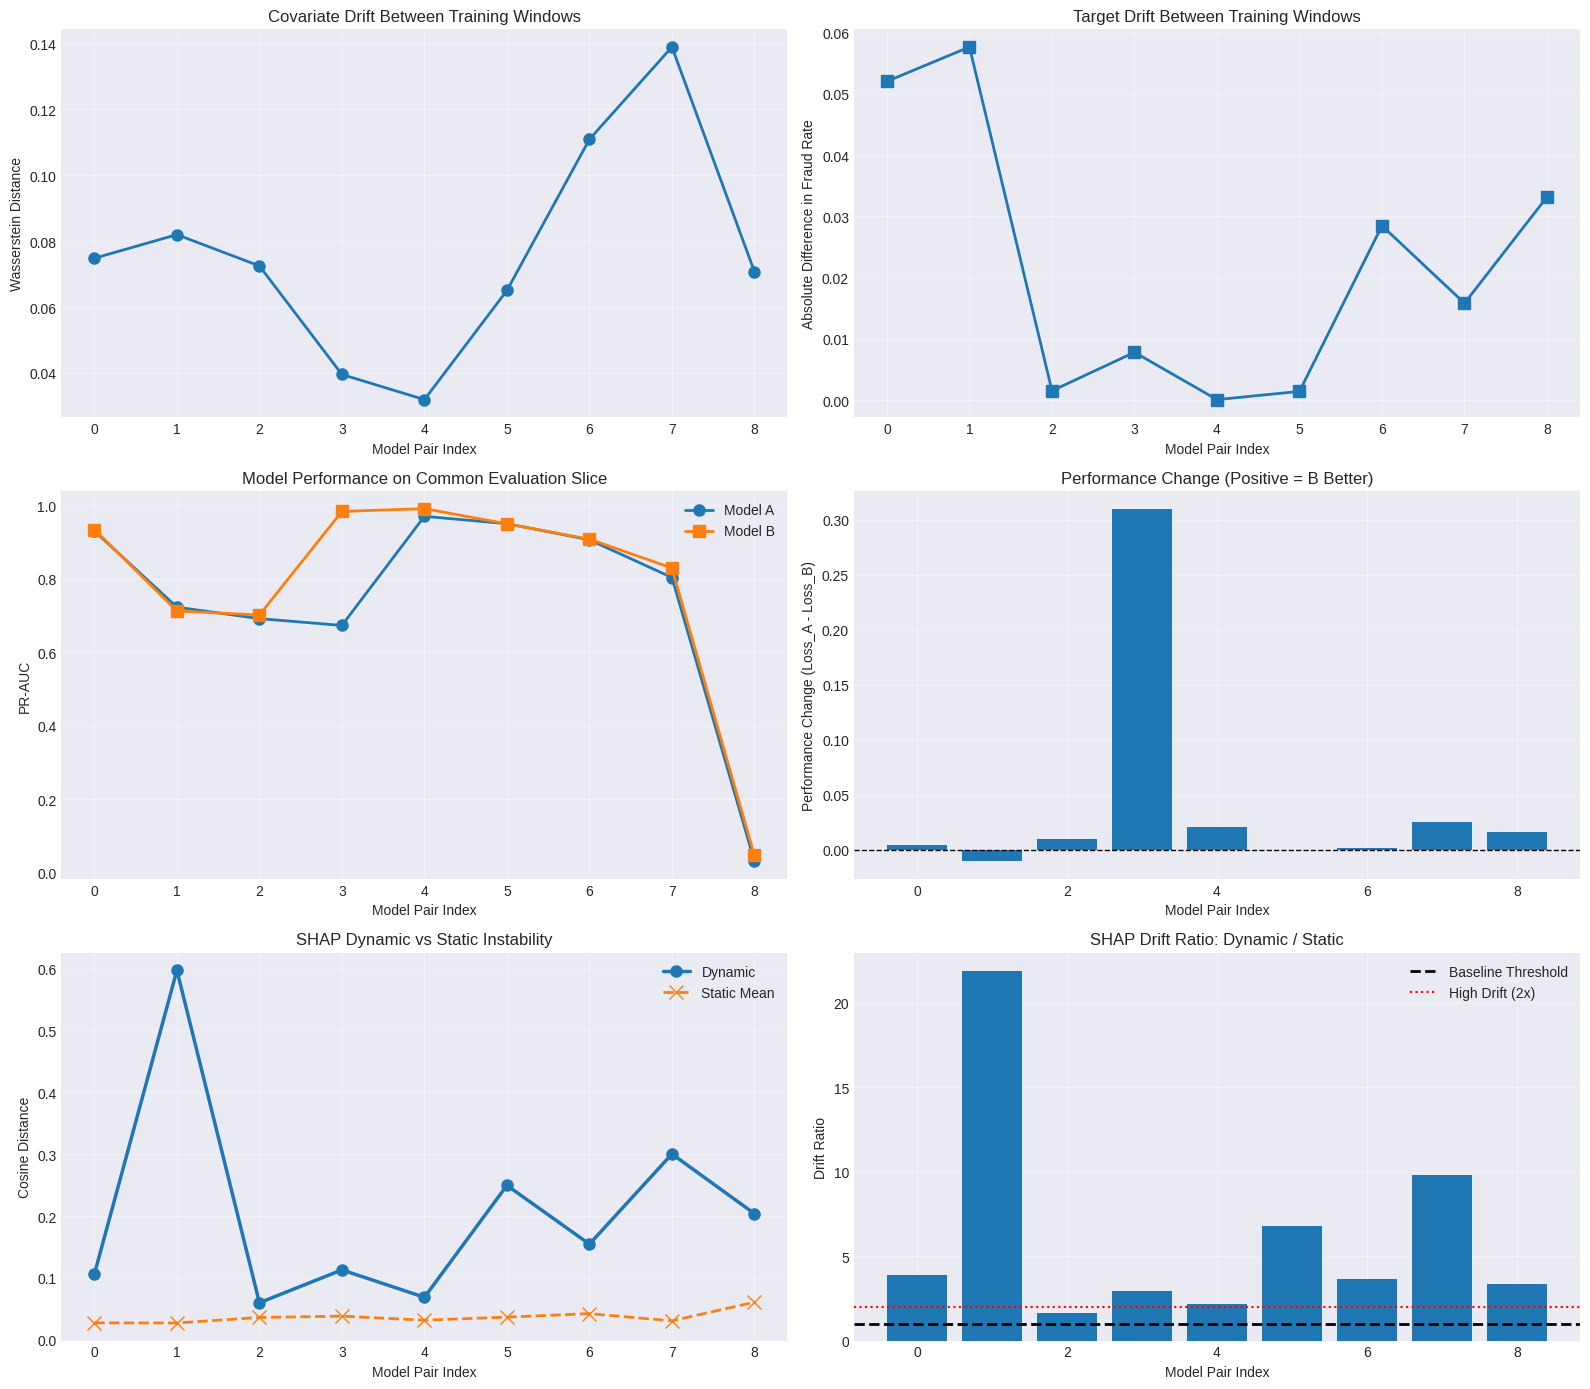

In [42]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

axes[0, 0].plot(results_df["pair_idx"], results_df["covariate_drift"], marker="o", linewidth=2, markersize=8)
axes[0, 0].set_xlabel("Model Pair Index")
axes[0, 0].set_ylabel("Wasserstein Distance")
axes[0, 0].set_title("Covariate Drift Between Training Windows")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(results_df["pair_idx"], results_df["target_drift"], marker="s", linewidth=2, markersize=8)
axes[0, 1].set_xlabel("Model Pair Index")
axes[0, 1].set_ylabel("Absolute Difference in Fraud Rate")
axes[0, 1].set_title("Target Drift Between Training Windows")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(results_df["pair_idx"], results_df["pr_auc_a"], marker="o", linewidth=2, markersize=8, label="Model A")
axes[1, 0].plot(results_df["pair_idx"], results_df["pr_auc_b"], marker="s", linewidth=2, markersize=8, label="Model B")
axes[1, 0].set_xlabel("Model Pair Index")
axes[1, 0].set_ylabel("PR-AUC")
axes[1, 0].set_title("Model Performance on Common Evaluation Slice")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].bar(results_df["pair_idx"], results_df["delta_perf"])
axes[1, 1].axhline(y=0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_xlabel("Model Pair Index")
axes[1, 1].set_ylabel("Performance Change (Loss_A - Loss_B)")
axes[1, 1].set_title("Performance Change (Positive = B Better)")
axes[1, 1].grid(True, alpha=0.3)

if "shap_dynamic_cos" in results_df.columns:
    axes[2, 0].plot(results_df["pair_idx"], results_df["shap_dynamic_cos"], marker="o", linewidth=2.5, markersize=8, label="Dynamic")
    axes[2, 0].plot(results_df["pair_idx"], results_df["shap_static_cos_mean"], marker="x", linewidth=2, markersize=10, linestyle="--", label="Static Mean")
    axes[2, 0].set_xlabel("Model Pair Index")
    axes[2, 0].set_ylabel("Cosine Distance")
    axes[2, 0].set_title("SHAP Dynamic vs Static Instability")
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].legend()

    axes[2, 1].bar(results_df["pair_idx"], results_df["shap_drift_ratio_cos"])
    axes[2, 1].axhline(y=1, color="black", linestyle="--", linewidth=2, label="Baseline Threshold")
    axes[2, 1].axhline(y=2, color="red", linestyle=":", linewidth=1.5, label="High Drift (2x)")
    axes[2, 1].set_xlabel("Model Pair Index")
    axes[2, 1].set_ylabel("Drift Ratio")
    axes[2, 1].set_title("SHAP Drift Ratio: Dynamic / Static")
    axes[2, 1].grid(True, alpha=0.3)
    axes[2, 1].legend()
else:
    axes[2, 0].text(0.5, 0.5, "SHAP analysis not performed", ha="center", va="center", transform=axes[2, 0].transAxes)
    axes[2, 1].text(0.5, 0.5, "SHAP analysis not performed", ha="center", va="center", transform=axes[2, 1].transAxes)

plt.tight_layout()
plt.show()

In [43]:
import numpy as np
import pandas as pd

if "results_df" not in globals():
    raise NameError("results_df is niet gedefinieerd. Run eerst het experimentblok waarin results_df wordt aangemaakt.")

if not isinstance(results_df, pd.DataFrame) or results_df.empty:
    raise ValueError("results_df is leeg of geen DataFrame.")

required_cols = [
    "pair_idx",
    "window_a_end",
    "window_b_end",
    "pr_auc_a",
    "pr_auc_b",
    "delta_perf",
    "target_drift",
    "covariate_drift",
    "shap_static_cos_a",
    "shap_static_rbo_a",
    "shap_static_cos_b",
    "shap_static_rbo_b",
    "shap_static_cos_mean",
    "shap_static_rbo_mean",
    "shap_explainer_instability_cos",
    "shap_explainer_instability_rbo",
    "lime_static_cos_a",
    "lime_static_rbo_a",
    "lime_static_cos_b",
    "lime_static_rbo_b",
    "lime_static_cos_mean",
    "lime_static_rbo_mean",
    "lime_explainer_instability_cos",
    "lime_explainer_instability_rbo",
    "shap_dynamic_cos",
    "shap_dynamic_rbo",
    "shap_drift_ratio_cos",
    "shap_drift_ratio_rbo",
    "shap_global_drift",
    "lime_dynamic_cos",
    "lime_dynamic_rbo",
    "lime_drift_ratio_cos",
    "lime_drift_ratio_rbo"
]

missing_cols = [col for col in required_cols if col not in results_df.columns]
if missing_cols:
    raise ValueError(
        "De volgende vereiste kolommen ontbreken in results_df: "
        + ", ".join(missing_cols)
        + ". Controleer of het experiment effectief met use_shap=True en use_lime=True is gerund."
    )

def _to_float(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan

def _fmt(x, width=8, decimals=4, na_label="N/A"):
    x = _to_float(x)
    if np.isnan(x):
        return f"{na_label:>{width}}"
    return f"{x:>{width}.{decimals}f}"

df_print = results_df.sort_values("pair_idx").reset_index(drop=True)

for _, row in df_print.iterrows():
    pair_idx = int(row["pair_idx"]) if not pd.isna(row["pair_idx"]) else "N/A"
    window_a_end = row["window_a_end"]
    window_b_end = row["window_b_end"]

    pr_auc_a = row["pr_auc_a"]
    pr_auc_b = row["pr_auc_b"]
    delta_perf = row["delta_perf"]
    target_drift = row["target_drift"]
    covariate_drift = row["covariate_drift"]

    shap_static_cos_a = row["shap_static_cos_a"]
    shap_static_rbo_a = row["shap_static_rbo_a"]
    shap_static_cos_b = row["shap_static_cos_b"]
    shap_static_rbo_b = row["shap_static_rbo_b"]
    shap_static_cos_mean = row["shap_static_cos_mean"]
    shap_static_rbo_mean = row["shap_static_rbo_mean"]
    shap_expl_cos = row["shap_explainer_instability_cos"]
    shap_expl_rbo = row["shap_explainer_instability_rbo"]

    lime_static_cos_a = row["lime_static_cos_a"]
    lime_static_rbo_a = row["lime_static_rbo_a"]
    lime_static_cos_b = row["lime_static_cos_b"]
    lime_static_rbo_b = row["lime_static_rbo_b"]
    lime_static_cos_mean = row["lime_static_cos_mean"]
    lime_static_rbo_mean = row["lime_static_rbo_mean"]
    lime_expl_cos = row["lime_explainer_instability_cos"]
    lime_expl_rbo = row["lime_explainer_instability_rbo"]

    shap_dynamic_cos = row["shap_dynamic_cos"]
    shap_dynamic_rbo = row["shap_dynamic_rbo"]
    shap_drift_ratio_cos = row["shap_drift_ratio_cos"]
    shap_drift_ratio_rbo = row["shap_drift_ratio_rbo"]
    shap_global_drift = row["shap_global_drift"]

    lime_dynamic_cos = row["lime_dynamic_cos"]
    lime_dynamic_rbo = row["lime_dynamic_rbo"]
    lime_drift_ratio_cos = row["lime_drift_ratio_cos"]
    lime_drift_ratio_rbo = row["lime_drift_ratio_rbo"]

    print("\n" + "=" * 88)
    print(f"PAIR {pair_idx} | window_a_end={window_a_end} | window_b_end={window_b_end}")
    print("=" * 88)

    print("\nTable 1: Performance & Data Drift")
    print("+----------+----------+----------+--------------+-----------------+")
    print("| PR-AUC A | PR-AUC B | Perf Δ   | Target Drift | Covariate Drift |")
    print("+==========+==========+==========+==============+=================+")
    print(
        f"| {_fmt(pr_auc_a, 8, 4)} | {_fmt(pr_auc_b, 8, 4)} | {_fmt(delta_perf, 8, 4)} | "
        f"{_fmt(target_drift, 12, 4)} | {_fmt(covariate_drift, 15, 4)} |"
    )
    print("+----------+----------+----------+--------------+-----------------+")

    print("\nTable 2: Static Baselines (Within-Window Instability)")
    print("+--------+-----------------+-----------------+---------------+--------------------+")
    print("| Method | Static A        | Static B        | Static Mean   | Explainer Instab.  |")
    print("|        |   Cos     RBO   |   Cos     RBO   |   Cos    RBO  |    Cos       RBO   |")
    print("+========+=================+=================+===============+====================+")
    print(
        f"| SHAP   | {_fmt(shap_static_cos_a, 7, 4)} {_fmt(shap_static_rbo_a, 7, 4)} | "
        f"{_fmt(shap_static_cos_b, 7, 4)} {_fmt(shap_static_rbo_b, 7, 4)} | "
        f"{_fmt(shap_static_cos_mean, 7, 4)} {_fmt(shap_static_rbo_mean, 7, 4)} | "
        f"{_fmt(shap_expl_cos, 10, 6)} {_fmt(shap_expl_rbo, 9, 6)} |"
    )
    print(
        f"| LIME   | {_fmt(lime_static_cos_a, 7, 4)} {_fmt(lime_static_rbo_a, 7, 4)} | "
        f"{_fmt(lime_static_cos_b, 7, 4)} {_fmt(lime_static_rbo_b, 7, 4)} | "
        f"{_fmt(lime_static_cos_mean, 7, 4)} {_fmt(lime_static_rbo_mean, 7, 4)} | "
        f"{_fmt(lime_expl_cos, 10, 4)} {_fmt(lime_expl_rbo, 9, 4)} |"
    )
    print("+--------+-----------------+-----------------+---------------+--------------------+")
    print("  → Static A/B: Retraining instability (bootstrap replicas within same window)")
    print("  → Explainer Instab.: Stochasticity inherent to XAI technique (same model, multiple runs)")

    print("\nTable 3: Dynamic Results (Cross-Window Temporal Drift)")
    print("+--------+-----------------+-------------+---------------+")
    print("| Method | Dynamic         | Drift Ratio | Global Drift  |")
    print("|        |   Cos     RBO   |  Cos   RBO  |      RBO      |")
    print("+========+=================+=============+===============+")
    print(
        f"| SHAP   | {_fmt(shap_dynamic_cos, 7, 4)} {_fmt(shap_dynamic_rbo, 7, 4)} | "
        f"{_fmt(shap_drift_ratio_cos, 5, 2)} {_fmt(shap_drift_ratio_rbo, 5, 2)} | "
        f"{_fmt(shap_global_drift, 13, 4)} |"
    )
    print(
        f"| LIME   | {_fmt(lime_dynamic_cos, 7, 4)} {_fmt(lime_dynamic_rbo, 7, 4)} | "
        f"{_fmt(lime_drift_ratio_cos, 5, 2)} {_fmt(lime_drift_ratio_rbo, 5, 2)} | "
        f"{'N/A':>13} |"
    )
    print("+--------+-----------------+-------------+---------------+")
    print("  → Dynamic: Cross-window instability (all replica pairs between windows A and B)")
    print("  → Drift Ratio: Dynamic / Static Mean (>1 indicates temporal drift exceeds retraining noise)")
    print("  → Global Drift: Feature importance ranking change between windows")


PAIR 0 | window_a_end=14 | window_b_end=19

Table 1: Performance & Data Drift
+----------+----------+----------+--------------+-----------------+
| PR-AUC A | PR-AUC B | Perf Δ   | Target Drift | Covariate Drift |
+==========+==========+==========+==============+=================+
|   0.9299 |   0.9340 |   0.0041 |       0.0521 |          0.0748 |
+----------+----------+----------+--------------+-----------------+

Table 2: Static Baselines (Within-Window Instability)
+--------+-----------------+-----------------+---------------+--------------------+
| Method | Static A        | Static B        | Static Mean   | Explainer Instab.  |
|        |   Cos     RBO   |   Cos     RBO   |   Cos    RBO  |    Cos       RBO   |
+========+=================+=================+===============+====================+
| SHAP   |  0.0427  0.2775 |  0.0122  0.1807 |  0.0274  0.2291 |   0.000000  0.000000 |
| LIME   |  0.2250  0.4315 |  0.1311  0.2788 |  0.1781  0.3552 |     0.0612    0.1210 |
+--------+----

In [44]:
if "results_df" not in globals():
    raise NameError("results_df is niet gedefinieerd. Run eerst het experimentblok waarin results_df wordt aangemaakt.")

pair_results_table = results_df[[
    "window_a_end",
    "window_b_end",
    "eval_start",
    "eval_end",
    "n_train_a",
    "n_valid_a",
    "n_train_b",
    "n_valid_b",
    "n_eval",
    "pr_auc_a",
    "pr_auc_b",
    "num_flagged",
    "pct_flagged",
    "fraud_rate_eval"
]].copy()

numeric_cols = pair_results_table.select_dtypes(include=[np.number]).columns
pair_results_table[numeric_cols] = pair_results_table[numeric_cols].round(4)

print("=" * 120)
print("PAIR-LEVEL RESULTS TABLE")
print("=" * 120)

display(pair_results_table)


PAIR-LEVEL RESULTS TABLE


,window_a_end,window_b_end,eval_start,eval_end,n_train_a,n_valid_a,n_train_b,n_valid_b,n_eval,pr_auc_a,pr_auc_b,num_flagged,pct_flagged,fraud_rate_eval
0,14,19,20,23,13164,1732,10061,1945,4491,0.9299,0.9340,456,10.1536,0.1271
1,17,22,23,26,11632,1959,8436,3304,3424,0.7227,0.7124,231,6.7465,0.1180
2,20,25,26,29,8990,2034,8825,2907,2181,0.6915,0.7014,309,14.1678,0.2448
3,23,28,29,32,8171,3591,9721,1007,3731,0.6730,0.9832,820,21.9780,0.2305
4,26,31,32,35,9316,2237,9163,2408,3620,0.9699,0.9909,569,15.7182,0.1613
5,29,34,35,38,9821,1664,9626,2279,4303,0.9499,0.9495,373,8.6684,0.0851
6,32,37,38,41,9526,2557,8601,3547,4282,0.9060,0.9077,415,9.6917,0.0981
7,35,40,41,44,10049,2297,9241,3150,6247,0.8034,0.8292,363,5.8108,0.0645
8,38,43,44,47,8755,2962,11384,4656,4370,0.0312,0.0474,32,0.7323,0.0121
